<a href="https://www.kaggle.com/code/allasamoilenko/fruit-classification?scriptVersionId=230582418" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [98]:
import torch
from torchvision import transforms, datasets
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report
import matplotlib.pyplot as plt
import os
import torch
from torchvision import transforms
from PIL import Image
import matplotlib.pyplot as plt
from torchvision.datasets import ImageFolder

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

In [4]:
data_dir = '/kaggle/input/fruit-recognition/train/train'
dataset = datasets.ImageFolder(root=data_dir)

In [6]:
dataset.classes

['Apple Braeburn',
 'Apple Granny Smith',
 'Apricot',
 'Avocado',
 'Banana',
 'Blueberry',
 'Cactus fruit',
 'Cantaloupe',
 'Cherry',
 'Clementine',
 'Corn',
 'Cucumber Ripe',
 'Grape Blue',
 'Kiwi',
 'Lemon',
 'Limes',
 'Mango',
 'Onion White',
 'Orange',
 'Papaya',
 'Passion Fruit',
 'Peach',
 'Pear',
 'Pepper Green',
 'Pepper Red',
 'Pineapple',
 'Plum',
 'Pomegranate',
 'Potato Red',
 'Raspberry',
 'Strawberry',
 'Tomato',
 'Watermelon']

In [9]:
len(dataset.classes)

33

In [47]:
transform = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
])
dataset = datasets.ImageFolder(root=data_dir)

In [48]:
from torch.utils.data import random_split

train_ratio = 0.8

train_data, val_data = random_split(dataset, [train_ratio, 1-train_ratio])

In [49]:
train_transform = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.ToTensor(),
])

test_transform = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.ToTensor(),
])


class TransformDataset(torch.utils.data.Dataset):
    def __init__(self, subset, transform=None):
        self.subset = subset
        self.transform = transform
        
    def __getitem__(self, index):
        x, y = self.subset[index]
        if self.transform:
            x = self.transform(x)
        return x, y
        
    def __len__(self):
        return len(self.subset)

    
train_data = TransformDataset(train_data, transform = train_transform)
val_data = TransformDataset(val_data, transform = test_transform)

In [50]:
batch_size = 32

train_loader = torch.utils.data.DataLoader(train_data, shuffle=True, batch_size=batch_size)
val_loader = torch.utils.data.DataLoader(val_data, shuffle=True, batch_size=batch_size)

In [51]:
import numpy as np
from torch import nn
import torch.nn.functional as F

class FruitClassifier(nn.Module):
    def __init__(self, num_classes=33):
        super().__init__()

        self.conv1 = nn.Conv2d(in_channels=3, out_channels=16, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(in_channels=16, out_channels=32, kernel_size=3, padding=1)
        self.conv3 = nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3, padding=1)
        self.conv4 = nn.Conv2d(in_channels=64, out_channels=128, kernel_size=3, padding=1)
        
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)
        
        self.flatten = nn.Flatten()
        
        # Розрахунок розміру після згорток та пулінгів для 64x64 зображення:
        # 64 -> pool(32) -> pool(16) -> pool(8) -> pool(4)
        self.linear1 = nn.Linear(128*4*4, 256)
        self.linear2 = nn.Linear(256, num_classes)
        
        self.dropout = nn.Dropout(0.5)

    def forward(self, x):
        # x - (batch, 3, 64, 64)
        out = self.pool(F.relu(self.conv1(x)))  # (batch, 16, 32, 32)
        out = self.pool(F.relu(self.conv2(out))) # (batch, 32, 16, 16)
        out = self.pool(F.relu(self.conv3(out))) # (batch, 64, 8, 8)
        out = self.pool(F.relu(self.conv4(out))) # (batch, 128, 4, 4)
        
        out = self.flatten(out) # (batch, 128*4*4)
        out = self.dropout(out)
        
        out = F.relu(self.linear1(out))
        out = self.dropout(out)
        out = self.linear2(out)
        
        return out


    def predict(self, X, device='cpu'):
        X = torch.FloatTensor(np.array(X)).to(device)

        with torch.no_grad():
            y_pred = F.softmax(self.forward(X), dim=-1)

        return y_pred.cpu().numpy()


model = FruitClassifier(len(dataset.classes)).to(device)

In [52]:
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
epochs = 5

In [53]:
def train(model, loader, criterion, optimizer):
    model.train()
    running_loss = 0.0
    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
    return running_loss / len(loader)

In [54]:
def evaluate(model, loader, criterion):
    model.eval()
    running_loss = 0.0
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)

            running_loss += loss.item()

            preds = torch.argmax(outputs, dim=1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    avg_loss = running_loss / len(loader)
    return avg_loss, all_preds, all_labels

In [55]:
for epoch in range(epochs):
    train_loss = train(model, train_loader, criterion, optimizer)
    val_loss, _, _ = evaluate(model, val_loader, criterion)
    print(f"Epoch [{epoch+1}/{epochs}], Train Loss: {train_loss:.4f}, Val Loss: {val_loss:.4f}")

Epoch [1/5], Train Loss: 1.7850, Val Loss: 0.4041
Epoch [2/5], Train Loss: 0.4916, Val Loss: 0.1449
Epoch [3/5], Train Loss: 0.2835, Val Loss: 0.0537
Epoch [4/5], Train Loss: 0.1992, Val Loss: 0.0279
Epoch [5/5], Train Loss: 0.1425, Val Loss: 0.0148


In [92]:
test_dir = '/kaggle/input/fruit-recognition/test'

In [99]:
train_data_dir = '/kaggle/input/fruit-recognition/train/train'
train_dataset = ImageFolder(root=train_data_dir)
class_names = train_dataset.classes  # отримання назв класів
idx_to_class = {v: k for k, v in train_dataset.class_to_idx.items()} 

In [100]:
test_transform = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.ToTensor(),
])

In [101]:
def classify_image(model, image_path, transform, device):
    image = Image.open(image_path).convert('RGB')
    image_tensor = transform(image).unsqueeze(0).to(device)
    
    model.eval()
    with torch.no_grad():
        outputs = model(image_tensor)
        _, predicted = torch.max(outputs, 1)
        probabilities = torch.nn.functional.softmax(outputs, dim=1)
    
    predicted_class_idx = predicted.item()
    confidence = probabilities[0][predicted_class_idx].item()
    predicted_class_name = idx_to_class[predicted_class_idx]
    
    return predicted_class_name, confidence, image

In [102]:
def classify_all_images(model, folder_path, transform, device):
    results = []
    valid_extensions = ('.jpg', '.jpeg', '.png', '.bmp')
    
    for filename in os.listdir(folder_path):
        if filename.lower().endswith(valid_extensions):
            try:
                image_path = os.path.join(folder_path, filename)
                class_name, confidence, image = classify_image(model, image_path, transform, device)
                results.append({
                    'filename': filename,
                    'predicted_class': class_name,
                    'confidence': confidence,
                    'image': image
                })
                print(f"Файл: {filename}, Прогноз: {class_name}, Впевненість: {confidence:.2f}")
            except Exception as e:
                print(f"Помилка при обробці {filename}: {str(e)}")
    
    return results

In [103]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = FruitClassifier(len(class_names)).to(device)
model.load_state_dict(torch.load('fruit_classifier.pth'))

<ipython-input-103-a3ee30f64254>:3: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load('fruit_classifier.pth'))


<All keys matched successfully>

In [104]:
classification_results = classify_all_images(model, test_dir, test_transform, device)

In [105]:
def visualize_predictions(results, num_images=12):
    num_images = min(num_images, len(results))
    fig, axes = plt.subplots(num_images // 4 + (1 if num_images % 4 > 0 else 0), 4, figsize=(20, 5 * (num_images // 4 + 1)))
    axes = axes.flatten()
    
    for i in range(num_images):
        result = results[i]
        axes[i].imshow(result['image'])
        axes[i].set_title(f"Прогноз: {result['predicted_class']}\nВпевненість: {result['confidence']:.2f}")
        axes[i].axis('off')
    
    for i in range(num_images, len(axes)):
        axes[i].axis('off')
    
    plt.tight_layout()
    plt.show()

In [106]:
visualize_predictions(classification_results)

ValueError: Number of rows must be a positive integer, not 0

<Figure size 2000x500 with 0 Axes>

In [107]:
def get_classification_statistics(results):
    class_counts = {}
    for result in results:
        class_name = result['predicted_class']
        if class_name in class_counts:
            class_counts[class_name] += 1
        else:
            class_counts[class_name] = 1
    
    # Сортування за кількістю зображень
    sorted_classes = sorted(class_counts.items(), key=lambda x: x[1], reverse=True)
    
    return sorted_classes

In [108]:
classification_stats = get_classification_statistics(classification_results)
print("\nРозподіл класів у тестовому наборі:")
for class_name, count in classification_stats:
    print(f"{class_name}: {count} зображень")


Розподіл класів у тестовому наборі:


In [96]:
model.eval()
all_preds = []
all_labels = []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        outputs = model(images)
        _, preds = torch.max(outputs, 1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.numpy())

ValueError: The number of FixedLocator locations (33), usually from a call to set_ticks, does not match the number of labels (1).

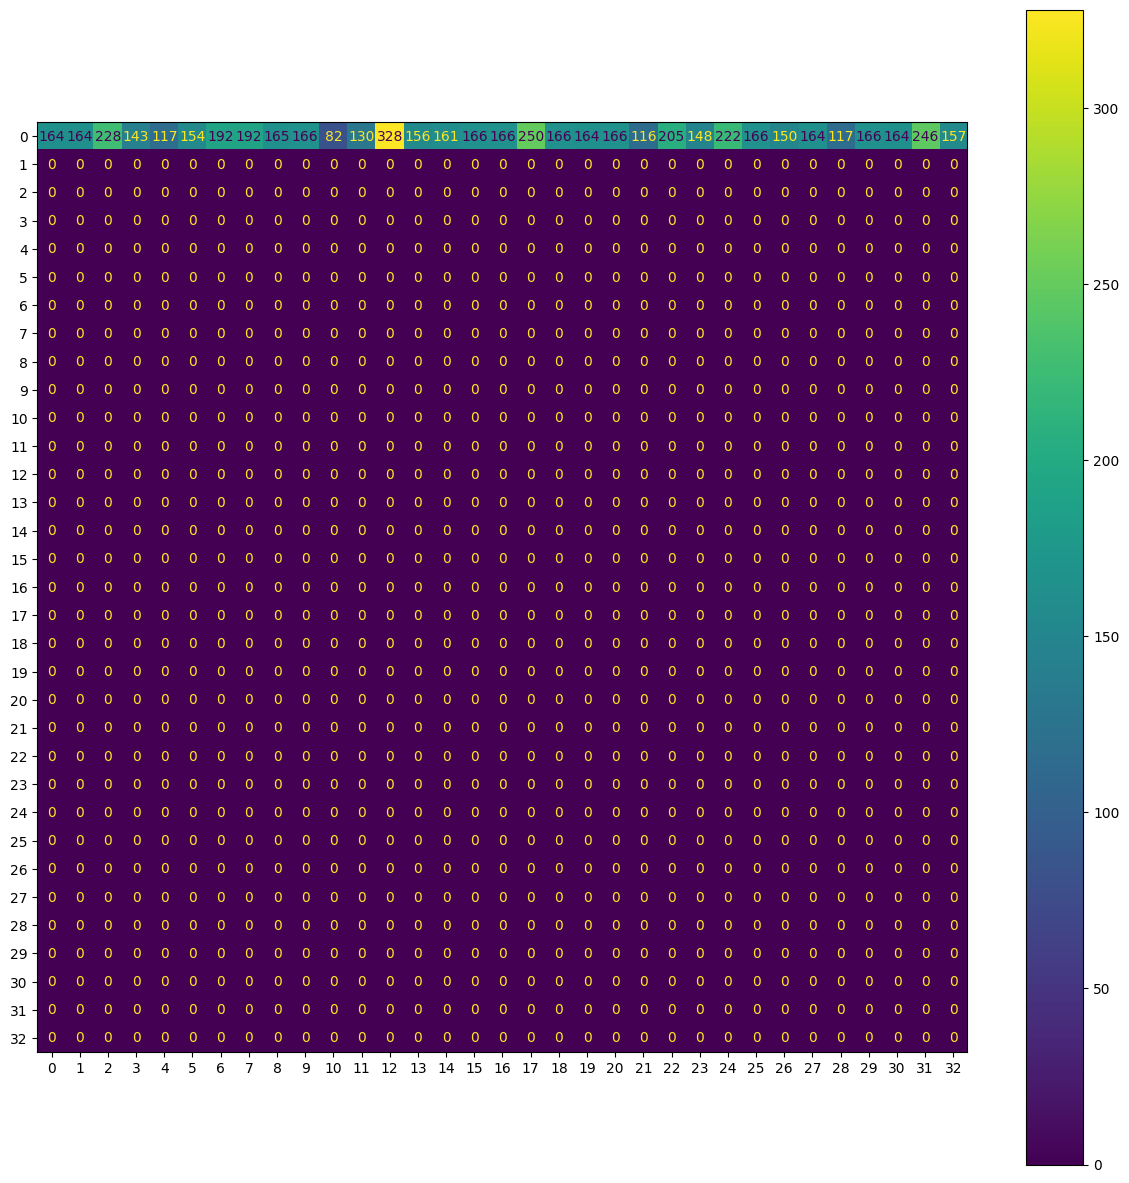

In [97]:
# Візуалізація матриці помилок
cm = confusion_matrix(all_labels, all_preds)
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm, 
    display_labels=test_dataset.classes
)
fig, ax = plt.subplots(figsize=(15, 15))
disp.plot(ax=ax, xticks_rotation=90)
plt.title('Confusion Matrix')
plt.show()

# Виведення повного звіту про класифікацію
print(classification_report(all_labels, all_preds, target_names=test_dataset.classes))

In [ ]:
torch.save(model.state_dict(), 'fruit_classifier.pth')